# Loss vs. Dimensions -- development notebook

Interactive counterpart to the standalone scripts in this folder, for iterating on the
loss-vs-dimensions pipeline (fundamental TM00, sidewall scattering + post-processed
non-uniform absorption -- see CLAUDE.md's repo-layout entry for this folder).

**Open item:** `emode_export.build_core_mask_from_geometry`'s trapezoid convention (which edge
`mask` sets, which way `sidewall_angle` tilts) is analytic, not read back from EMode, and is
still unverified. Section 1 below is the geometry sanity check for that.

In [1]:
import sys, os, importlib, json
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'phase_matching_pipeline'))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import emode_helpers as pmh
import absorption_model as am
import emode_export as ee
import sweep_loss_vs_dimensions as sw
import plot_loss_vs_dimensions as plv
import scattering_model as scm
import calibrate_scattering as cs

## 1. Verify the core geometry mask convention

Solves one point and plots the shapes/index -- confirm `core` is centered on x=0, `w_core` nm
wide, `h_core` nm tall, narrowing (not widening) toward the top under a positive
`sidewall_angle`. If it looks flipped, fix the sign on the `frac` term in
`emode_export.build_core_mask_from_geometry` to match.

In [2]:
h_check, w_check = 340.0, 400.0

em = pmh.launch_session('geometry_check', clear='all')
try:
    pmh.setup_waveguide(em, sw.ANISOTROPIC_EQUATION, h_check, w_check,
                         sidewall_angle=sw.SIDEWALL_ANGLE)
    em.settings(wavelength=sw.WAVELENGTH_PUMP, num_modes=2,
                x_resolution=sw.X_RESOLUTION, y_resolution=sw.Y_RESOLUTION)
    em.FDM()
    em.plot(component='Shapes')  # opens an interactive window -- close it to continue
    em.plot(component='Index')
finally:
    em.close(save=False)

Headless alternative (saves PNGs instead of opening a window -- useful for sharing/review;
`file_name` must be an absolute path, see CLAUDE.md's known gotchas):

In [ ]:
em = pmh.launch_session('geometry_check', clear='all')
try:
    pmh.setup_waveguide(em, sw.ANISOTROPIC_EQUATION, h_check, w_check,
                         sidewall_angle=sw.SIDEWALL_ANGLE)
    em.settings(wavelength=sw.WAVELENGTH_PUMP, num_modes=2,
                x_resolution=sw.X_RESOLUTION, y_resolution=sw.Y_RESOLUTION)
    em.FDM()
    em.plot(component='Shapes', file_name=os.path.abspath('geometry_check_shapes.png'))
    em.plot(component='Index', file_name=os.path.abspath('geometry_check_index.png'))
finally:
    em.close(save=False)

Cross-check `build_core_mask_from_geometry` against the same point -- overlay the analytic
mask's outline and compare it by eye to the plots above.

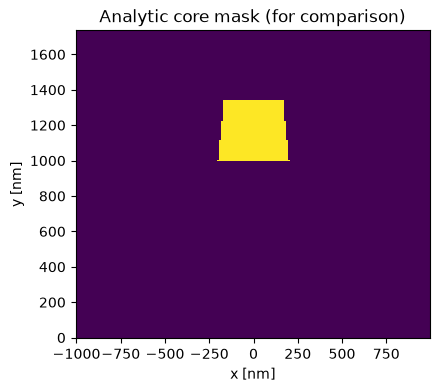

In [3]:
x_dummy = np.arange(-1000.0, 1000.0, sw.X_RESOLUTION)
y_dummy = np.arange(0.0, sw.SUBSTRATE_HEIGHT + h_check + 400.0, sw.Y_RESOLUTION)
# confirmed via em.plot() above: the core sits directly on top of the substrate, at
# y=SUBSTRATE_HEIGHT -- not centered in the window
mask = ee.build_core_mask_from_geometry(x_dummy, y_dummy, h_check, w_check, sw.SIDEWALL_ANGLE,
                                         sw.SUBSTRATE_HEIGHT)

plt.figure(figsize=(5, 4))
plt.pcolormesh(x_dummy, y_dummy, mask, shading='auto')
plt.xlabel('x [nm]'); plt.ylabel('y [nm]'); plt.title('Analytic core mask (for comparison)')
plt.gca().set_aspect('equal')

## 2. Re-run the EMode-output diagnostic (optional)

Only needed again if you change solver settings enough to worry the return shapes/units
might differ (e.g. switching to EME, or a very different geometry) -- otherwise skip to 3.

In [ ]:
import inspect_emode_outputs
importlib.reload(inspect_emode_outputs)
inspect_emode_outputs.main()

## 3. Run the loss-vs-dimensions sweep

**Cell A**: edit the height/width sweep range here (overrides `sw.HEIGHTS`/`sw.WIDTHS` after
reloading, so this doesn't get clobbered by the reload). Roughness assumptions
(`ROUGHNESS_RMS`/`CORRELATION_LENGTH`) and solver settings are still only in
`sweep_loss_vs_dimensions.py` itself -- edit those there if needed.

**Cell B**: runs the sweep. Checkpointed: re-running skips points already done in
`loss_vs_dimensions_results.csv` under the current roughness assumptions, so an interrupted
run, one transient EMode.exe failure (see CLAUDE.md's known gotchas), or just adding new
heights/widths only costs the points not yet solved.

In [2]:
importlib.reload(ee)
importlib.reload(sw)

# Edit the sweep range here, then run Cell B. Defaults below match sweep_loss_vs_dimensions.py's
# own HEIGHTS/WIDTHS -- only change what you need to.
HEIGHTS = [300.0, 340.0, 380.0]      # [nm]
HEIGHTS = np.arange(400,1001,200)     # [nm]
WIDTHS = np.arange(300.0, 1001.0, 50.0)  # [nm]

sw.HEIGHTS = HEIGHTS
sw.WIDTHS = WIDTHS
sw.TARGET_POINTS = [(h, w) for h in HEIGHTS for w in WIDTHS]
print(f'Sweep range set: {len(HEIGHTS)} height(s) x {len(WIDTHS)} width(s) = {len(sw.TARGET_POINTS)} point(s)')

Sweep range set: 4 height(s) x 15 width(s) = 60 point(s)


In [3]:
sw.main()

68 point(s) already done, 37 remaining.

=== h=600, w=400.0 ===
  n_eff=2.09562, TE_fraction=0.0004726, scattering: sum=631, vertical=629, horizontal=1.48 dB/m

=== h=600, w=450.0 ===
  n_eff=2.10764, TE_fraction=0.0004112, scattering: sum=453, vertical=452, horizontal=1.49 dB/m

=== h=600, w=500.0 ===
  n_eff=2.11649, TE_fraction=0.0003639, scattering: sum=336, vertical=335, horizontal=1.5 dB/m

=== h=600, w=550.0 ===
  n_eff=2.12318, TE_fraction=0.0003263, scattering: sum=256, vertical=255, horizontal=1.49 dB/m

=== h=600, w=600.0 ===
  n_eff=2.12837, TE_fraction=0.0002951, scattering: sum=200, vertical=198, horizontal=1.49 dB/m

=== h=600, w=650.0 ===
  n_eff=2.13246, TE_fraction=0.0002691, scattering: sum=159, vertical=158, horizontal=1.49 dB/m

=== h=600, w=700.0 ===
  n_eff=2.13575, TE_fraction=0.0002465, scattering: sum=129, vertical=127, horizontal=1.49 dB/m

=== h=600, w=750.0 ===
  n_eff=2.13843, TE_fraction=0.0002269, scattering: sum=106, vertical=104, horizontal=1.49 dB/m



## 4. Fit scattering-model calibration factor

`scattering_model.py`'s Payne-Lacey adaptation is uncalibrated by construction (see its module
docstring). This fits ONE global `calibration_factor` by least-squares against every point in
the sweep (using each point's own sidewall roughness_rms[0]/correlation_length[0] -- the
vertical/sidewall value, matching EMode's own [vertical, horizontal] convention), reports a
per-point table, and persists the fit to `scattering_calibration.json` so later sections (and
any future python-only exploration, per the plan to eventually skip EMode entirely once
calibrated) can just load it instead of re-fitting.

In [4]:
import scattering_model as scm
import calibrate_scattering as cs
importlib.reload(scm)
importlib.reload(cs)
calibration = cs.fit_and_report()

Fitted sidewall-scattering calibration_factor = 0.92184 (R^2=0.9903, n_core=2.1109, n_clad=1.4700, 105 point(s))

     h      w  EMode vert.    PL uncal.    PL cal.    ratio
   300    300        987.4         1211       1116    1.131
   300    350        662.3          834      768.9    1.161
   300    400        465.9        584.1      538.4    1.156
   300    450        339.7        434.6      400.6    1.179
   300    500        255.6        324.1      298.7    1.169
   300    550        196.9        254.1      234.3    1.190
   300    600        155.2          198      182.5    1.176
   300    650        124.3        161.2      148.6    1.196
   300    700        101.2        129.7      119.5    1.181
   300    750        83.43        108.6      100.1    1.200
   300    800        69.68         89.5      82.51    1.184
   300    850        58.71        76.59       70.6    1.203
   300    900        50.01        64.36      59.33    1.186
   300    950        42.88        56.03      5

## 5. Plot results

Uses `plot_loss_vs_dimensions.py`'s `MECHANISMS` list -- produces the totals figure
(`loss_vs_dimensions.png`) plus a per-physical-mechanism breakdown figure
(`loss_by_mechanism.png`, one subplot per height).

Saved loss_vs_dimensions.png
Saved loss_by_mechanism.png


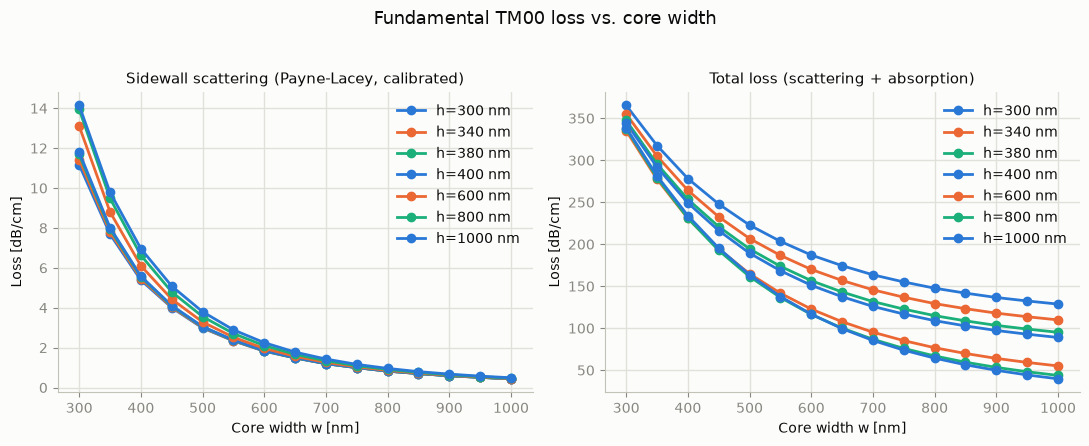

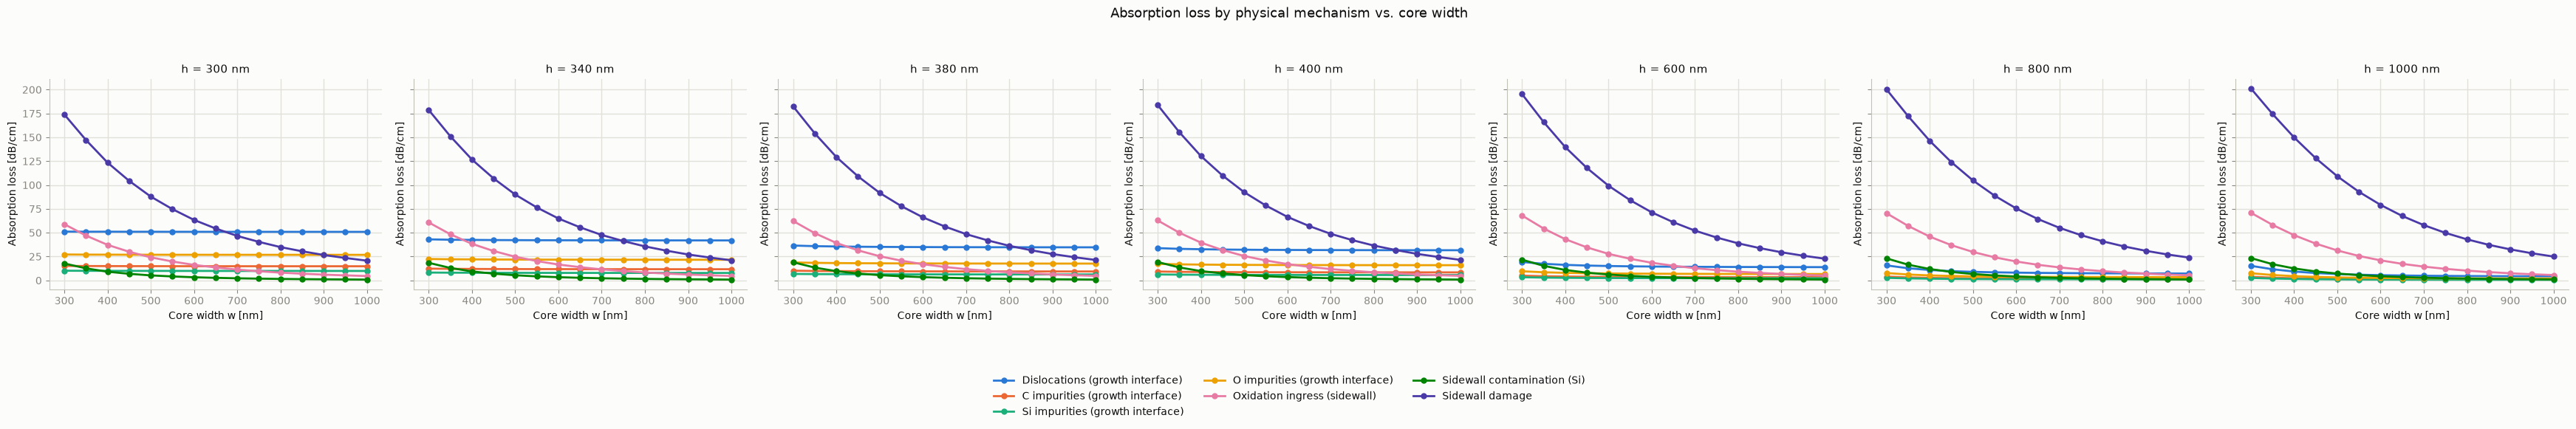

In [5]:
import calibrate_scattering as cs
importlib.reload(plv)

calibration = cs.load_calibration()
assumptions = plv.default_assumptions()
assumptions.update(n_core=calibration['n_core'], n_clad=calibration['n_clad'],
                    n_substrate=calibration['n_substrate'],
                    calibration_factor=calibration['calibration_factor'],
                    calibration_factor_horizontal=calibration['calibration_factor_horizontal'])
plv.main(assumptions)

## 6. Explore absorption assumptions interactively (no EMode calls)

Loads the sweep's exported fields directly and lets you sweep alpha0/L by hand -- faster
than editing `plot_loss_vs_dimensions.py` and re-running for quick exploration.

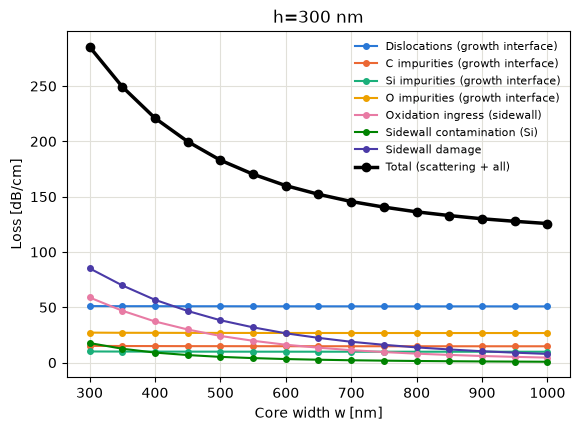

In [10]:
import copy

# Start from plot_loss_vs_dimensions.py's MECHANISMS list (single source of truth) and tweak
# whichever one(s) you're investigating -- deepcopy so this doesn't mutate the shared list.
mechanisms = copy.deepcopy(plv.MECHANISMS)
for m in mechanisms:
    if m['name'] == 'Sidewall damage':
        m['alpha0'] = 3.0e4
        m['L'] = 60.0

rows = plv.load_results(sw.RESULTS_CSV)
h_pick = sorted(set(r['h_core'] for r in rows))[0]
h_rows = sorted((r for r in rows if r['h_core'] == h_pick), key=lambda r: r['w_core'])

widths, totals = [], []
per_mechanism = {m['name']: [] for m in mechanisms}
for r in h_rows:
    data = np.load(r['export_path'])
    losses = am.compute_mechanism_losses(
        data['core_mask'], dx=float(data['x'][1] - data['x'][0]), y=data['y'], Sz=data['Sz'],
        mechanisms=mechanisms)
    widths.append(r['w_core'])
    totals.append((r['scattering_loss_dB_per_m'] + sum(losses.values())) / 100)  # dB/cm
    for name, val in losses.items():
        per_mechanism[name].append(val / 100)

plt.figure(figsize=(6.5, 4.5))
for i, (name, vals) in enumerate(per_mechanism.items()):
    plt.plot(widths, vals, '-o', color=plv.MECHANISM_COLORS[i % len(plv.MECHANISM_COLORS)],
             markersize=4, label=name)
plt.plot(widths, totals, '-o', color='black', linewidth=2.5, label='Total (scattering + all)')
plt.xlabel('Core width w [nm]'); plt.ylabel('Loss [dB/cm]')
plt.title(f'h={h_pick:.0f} nm')
plt.legend(fontsize=8, frameon=False)
plt.grid(True, color='#e1e0d9'); plt.gca().set_axisbelow(True)

## 7. Compare Payne-Lacey (adapted) vs. EMode-native scattering

`scattering_model.py`'s absolute scale is uncalibrated by construction (see its module
docstring) -- the first cell below fits a single `calibration_factor` by matching one
reference width exactly, then the second cell applies that same factor across every width at
this height so you can see whether the *trend* (not just that one point) tracks EMode's
native Volume-Current-Method result. Both cells re-run instantly -- no EMode calls -- so
tweak `n_core`/`n_clad` (only rough Sellmeier-based defaults below) or `ref_index` and re-fit
freely.

In [6]:
# Reuse the global fit from Section 4 (calibration = cs.fit_and_report()) instead of
# re-deriving a per-height/single-point factor -- one calibration_factor, one source of truth.
n_core, n_clad = calibration['n_core'], calibration['n_clad']
calibration_factor = calibration['calibration_factor']

rows = plv.load_results(sw.RESULTS_CSV)
h_pick = sorted(set(r['h_core'] for r in rows))[0]
h_rows = sorted((r for r in rows if r['h_core'] == h_pick), key=lambda r: r['w_core'])
print(f'Using calibration_factor={calibration_factor:.6g} (global fit, R^2={calibration["r_squared"]:.4f})')

Using calibration_factor=0.92184 (global fit, R^2=0.9903)


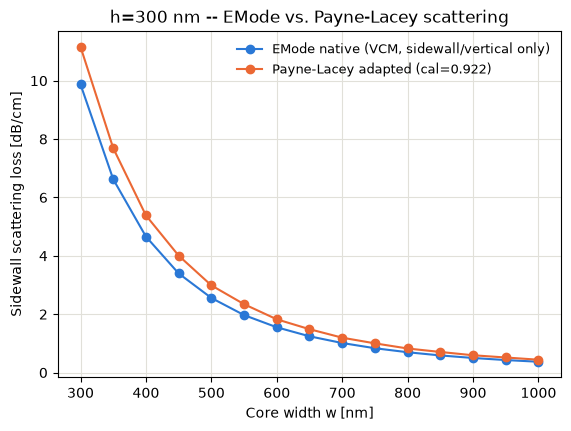

In [7]:
widths, emode_dB_cm, pl_dB_cm = [], [], []
for r in h_rows:
    data = np.load(r['export_path'])
    sigma = json.loads(r['roughness_rms'])[0]
    Lc = json.loads(r['correlation_length'])[0]
    pl = scm.compute_scattering_loss(data, n_core, n_clad, sigma, Lc,
                                      calibration_factor=calibration_factor)
    widths.append(r['w_core'])
    emode_dB_cm.append(r['scattering_vertical_dB_per_m'] / 100)
    pl_dB_cm.append(pl / 100)

plt.figure(figsize=(6.5, 4.5))
plt.plot(widths, emode_dB_cm, '-o', color='#2a78d6', label='EMode native (VCM, sidewall/vertical only)')
plt.plot(widths, pl_dB_cm, '-o', color='#eb6834',
         label=f'Payne-Lacey adapted (cal={calibration_factor:.3g})')
plt.xlabel('Core width w [nm]'); plt.ylabel('Sidewall scattering loss [dB/cm]')
plt.title(f'h={h_pick:.0f} nm -- EMode vs. Payne-Lacey scattering')
plt.legend(frameon=False, fontsize=9)
plt.grid(True, color='#e1e0d9'); plt.gca().set_axisbelow(True)

## 8. Live loss-contributor assumptions -- jump straight here

Fully self-contained: only depends on `loss_vs_dimensions_results.csv`, `field_exports/`, and
`scattering_calibration.json` already existing on disk (from Sections 3-4, run once). No EMode
calls anywhere below -- safe to skip 1-7 and re-run just this section repeatedly while tuning
assumptions.

**Cell A** loads everything read-only. **Cell B is the one editable cell** -- every
loss-contributor assumption (sidewall scattering's sigma/Lc/n_core/n_clad/calibration_factor,
plus all 7 absorption mechanisms) lives there in one place; edit it and re-run Cell C to see
the update. Nothing above Cell B needs to change for day-to-day use.

In [43]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import plot_loss_vs_dimensions as plv
import scattering_model as scm
import absorption_model as am
import sweep_loss_vs_dimensions as sw
import calibrate_scattering as cs

# defensive reloads -- guarantees fresh code even if this kernel already had stale versions
# of these modules loaded from earlier in the session (plain `import` alone would NOT
# re-execute an already-imported module)
for _m in (scm, am, sw, plv, cs):
    importlib.reload(_m)

rows = plv.load_results(sw.RESULTS_CSV)
heights = sorted(set(r['h_core'] for r in rows))
calibration = cs.load_calibration()
print(f"Loaded {len(rows)} point(s) across heights {heights}")
print(f"Loaded calibration: factor={calibration['calibration_factor']:.6g} "
      f"(R^2={calibration['r_squared']:.4f}), "
      f"horizontal factor={calibration['calibration_factor_horizontal']:.6g} "
      f"(R^2={calibration['r_squared_horizontal']:.4f}), "
      f"n_core={calibration['n_core']:.4f}, n_clad={calibration['n_clad']:.4f}, "
      f"n_substrate={calibration['n_substrate']:.4f}")

Loaded 105 point(s) across heights [300.0, 340.0, 380.0, 400.0, 600.0, 800.0, 1000.0]
Loaded calibration: factor=0.92184 (R^2=0.9903), horizontal factor=1.30169 (R^2=0.9835), n_core=2.1109, n_clad=1.4700, n_substrate=1.7760


In [55]:
# ============================================================================================
# ALL LOSS-CONTRIBUTOR ASSUMPTIONS -- edit this cell, then re-run Cell C below
# ============================================================================================

# --- Sidewall scattering (Payne-Lacey, calibrated against EMode's native VCM result) --------
N_CORE = calibration['n_core']              # AlN core index -- from the calibration fit
N_CLAD = calibration['n_clad']              # sidewall-cladding index -- from the calibration fit
N_SUBSTRATE = calibration['n_substrate']    # substrate (e.g. sapphire) index -- from the fit
CALIBRATION_FACTOR = calibration['calibration_factor']   # sidewall (vertical) fit
CALIBRATION_FACTOR_HORIZONTAL = calibration['calibration_factor_horizontal']  # top/bottom fit
SIGMA_SIDEWALL_NM = 2.0                     # RMS sidewall roughness [nm]
LC_SIDEWALL_NM = 50.0                       # sidewall roughness correlation length [nm]
SIGMA_HORIZONTAL_NM = 0.3                   # RMS top/bottom roughness [nm]
LC_HORIZONTAL_NM = 10.0                     # top/bottom roughness correlation length [nm]

# --- Non-uniform absorption mechanisms -------------------------------------------------------
# localization: 'interface' (varies with height above the core/substrate interface) or
#               'sidewall' (varies with lateral distance from the nearest sidewall)
# shape: 'step' or 'exp'; alpha0 [dB/m] = LOCAL coefficient at the boundary; L [nm] = penetration depth
MECHANISMS = [
    {'name': 'Dislocations (growth interface)',  'localization': 'interface', 'shape': 'exp',  'alpha0': 1.0e4/4, 'L': 40.0},
    {'name': 'C impurities (growth interface)',   'localization': 'interface', 'shape': 'exp',  'alpha0': 1.5e4/4, 'L': 20.0},
    {'name': 'Si impurities (growth interface)',  'localization': 'interface', 'shape': 'exp',  'alpha0': 1.0e4/4, 'L': 20.0},
    {'name': 'O impurities (growth interface)',   'localization': 'interface', 'shape': 'exp',  'alpha0': 2.0e4/4, 'L': 20.0},
    {'name': 'Oxidation ingress (sidewall)',      'localization': 'sidewall',  'shape': 'exp',  'alpha0': 2.0e4/4, 'L': 20.0},
    {'name': 'Sidewall contamination (Si)',       'localization': 'sidewall',  'shape': 'step', 'alpha0': 1.5e4/4, 'L': 15.0},
    {'name': 'Sidewall damage',                   'localization': 'sidewall',  'shape': 'exp',  'alpha0': 0.0e4/4, 'L': 50.0},
]

assumptions = {'mechanisms': MECHANISMS, 'n_core': N_CORE, 'n_clad': N_CLAD,
               'n_substrate': N_SUBSTRATE,
               'sigma_sidewall': SIGMA_SIDEWALL_NM, 'Lc_sidewall': LC_SIDEWALL_NM,
               'sigma_horizontal': SIGMA_HORIZONTAL_NM, 'Lc_horizontal': LC_HORIZONTAL_NM,
               'calibration_factor': CALIBRATION_FACTOR,
               'calibration_factor_horizontal': CALIBRATION_FACTOR_HORIZONTAL}

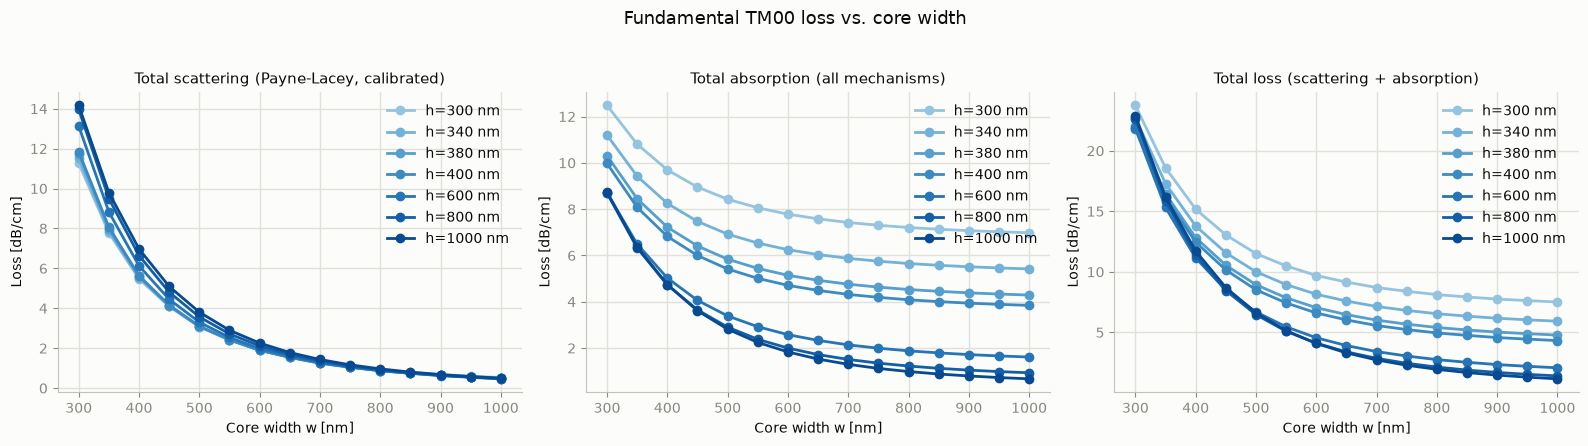

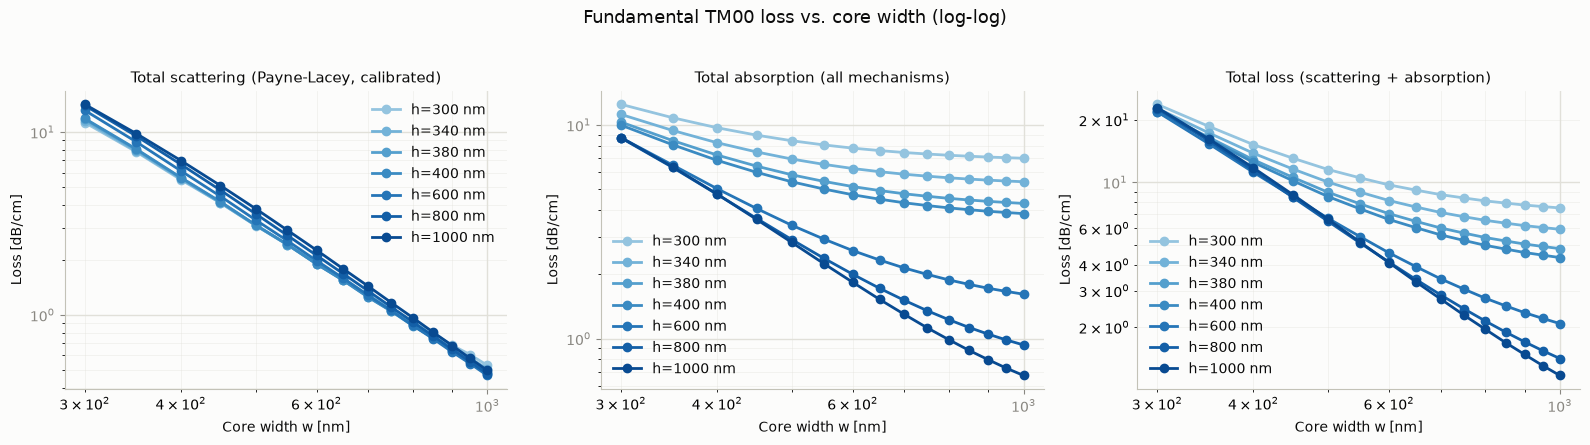

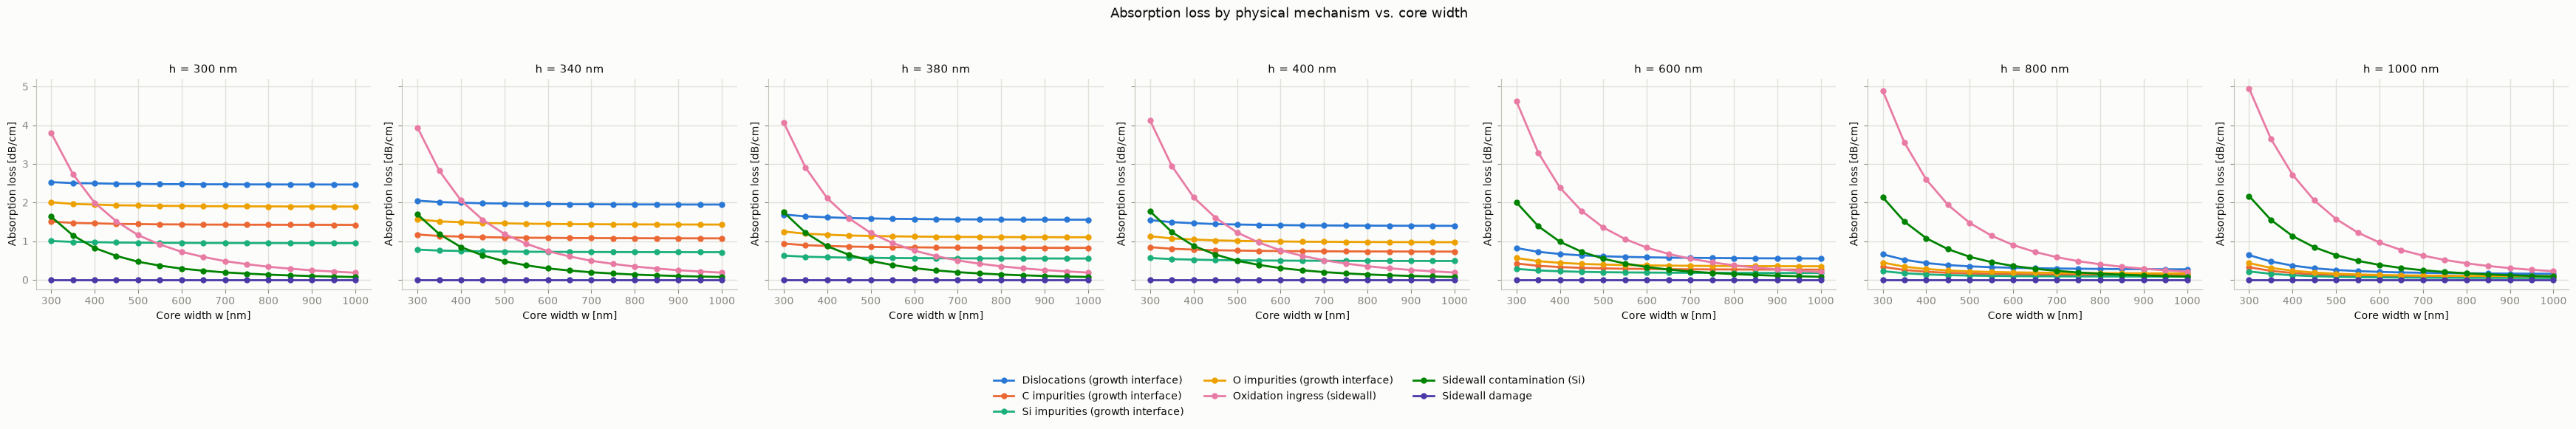

In [56]:
fig_totals = plv.plot_totals(rows, heights, assumptions)
fig_totals_log = plv.plot_totals(rows, heights, assumptions, log_scale=True)
fig_breakdown = plv.plot_mechanism_breakdown(rows, heights, assumptions)
plt.show()

**Optional: 3D surface, Loss = f(h, w)** -- plotted directly off the sweep's regular grid (no
curve fitting; see `plot_loss_surface`'s docstring for why that's unnecessary here). Needs
>=2 distinct heights AND widths in `rows` to mean anything -- if your sweep only has one
height, this just prints why and returns `None` rather than erroring.

`quantity`: `'total'`, `'scattering'`, or any mechanism name from `MECHANISMS` above (e.g.
`'Sidewall damage'`) to see that one contributor's (h, w) dependence alone.

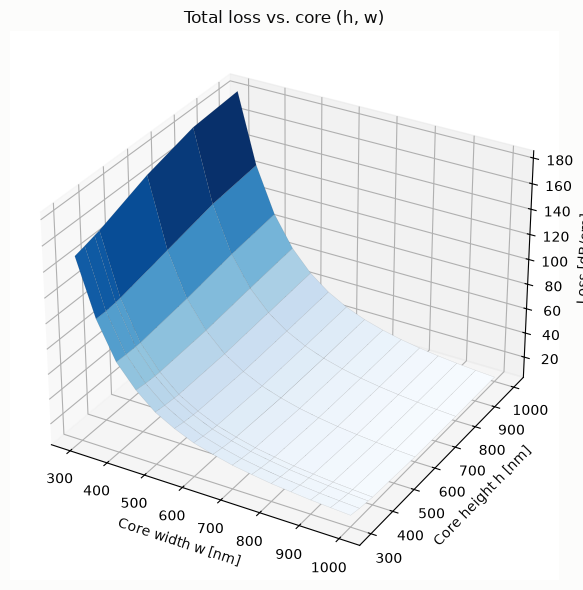

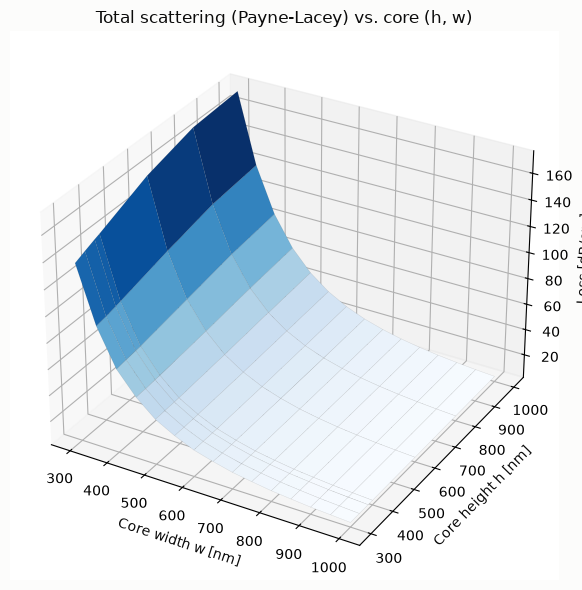

In [46]:
plv.plot_loss_surface(rows, assumptions, quantity='total')
plv.plot_loss_surface(rows, assumptions, quantity='scattering')
plt.show()

## 9. Verify TM00 mode identity across the sweep

Post-hoc check, no EMode calls -- works on every point in `field_exports/`, including ones
solved before the live `TE_fraction` warning existed in `sweep_loss_vs_dimensions.py` (that
value was only ever printed at solve time, never saved anywhere). Plots `|Ex|`, `|Ey|`, `|Ez|`
for each point to `field_profile_plots/` (with the core outline overlaid) and reports a
quasi-TE/quasi-TM energy-fraction proxy -- flags any point where the in-plane (Ex, "TE-like")
energy fraction exceeds 10%. This proxy isn't guaranteed to exactly reproduce EMode's own
`TE_fraction` (computed internally from the full mode solution, not re-derivable from the
exported E-field alone) -- treat the field plots as the more trustworthy verification, this
number as a fast first pass.

In [ ]:
import importlib
import verify_mode_profiles as vmp
importlib.reload(vmp)
results = vmp.main()